<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

## Step 2.0 — Setup

In [ ]:
import os
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()

# Folder + file constants. _FOLDER = a directory, _FILE = a single file.
TUTORIALS_FOLDER = Path("tutorials")
DATA_FOLDER = TUTORIALS_FOLDER / "data"
SNAPSHOT_FOLDER = DATA_FOLDER / "snapshots"
CROP_FOLDER = DATA_FOLDER / "crops"
DB_FILE = DATA_FOLDER / "birds.db"
SAMPLE_BIRD_FILE = DATA_FOLDER / "samples" / "sample-bird.jpg"
MODEL_FILE = TUTORIALS_FOLDER / "yolov8n.pt"

# From .env (or hardcoded fallback for Colab)
PHONE_IP = os.environ.get("PHONE_IP", "192.168.1.42")
PHONE_URL = f"http://{PHONE_IP}:8080/photo.jpg"
SLACK_WEBHOOK = os.environ.get("SLACK_WEBHOOK", "")
HUGGINGFACE_API_KEY = os.environ.get("HUGGINGFACE_API_KEY", "")

SNAPSHOT_FOLDER.mkdir(parents=True, exist_ok=True)
CROP_FOLDER.mkdir(parents=True, exist_ok=True)
print(f"Snapshot folder: {SNAPSHOT_FOLDER}")
print(f"Phone URL: {PHONE_URL}")

Snapshot folder: tutorials/data/snapshots
Phone URL: http://192.168.1.207:8080/photo.jpg


## Step 2.1 — The camera is just a web page

IP Webcam (the Android app) serves photos at `http://PHONE_IP:8080/photo.jpg`. Open that URL in a browser — you'll see a single JPEG. We can grab that same JPEG with Python.

In [ ]:
import requests

response = requests.get(PHONE_URL, timeout=10)
response.raise_for_status()
print("Got", len(response.content), "bytes")

Got 492793 bytes


## Step 2.2 — Save with a timestamped filename

Two photos can't have the same name. Use the current date and time.

In [ ]:
from datetime import datetime
from pathlib import Path

SNAPSHOT_FOLDER.mkdir(parents=True, exist_ok=True)
snapshot_file = SNAPSHOT_FOLDER / f"{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.jpg"
snapshot_file.write_bytes(response.content)
print("Saved:", snapshot_file)

Saved: tutorials/data/snapshots/2026-07-07_23-46-57.jpg


## Step 2.3 — Wrap as `get_image_from_camera`

The `#| export` directive tells nbdev: *'write this function to `bird_watcher/get_image.py`'*.

In [0]:
#| echo: false
#| output: asis
show_doc(get_image_from_camera)

---

### get_image_from_camera

```python
def get_image_from_camera(
    camera_url:str, snapshot_folder:str, timeout_seconds:float=10.0
)->Path:
```

*Grab one photo from the camera and save it with a timestamp filename.*

Args:
    camera_url: where to ask for a photo. Usually `http://PHONE_IP:8080/photo.jpg`.
    snapshot_folder: which folder to write the photo into. Created if missing.
    timeout_seconds: how long to wait before giving up.

Returns:
    Path to the saved JPEG.

## Step 2.4 — Add `get_images_from_camera`

Loop + sleep + Stop-friendly.

In [0]:
#| echo: false
#| output: asis
show_doc(get_images_from_camera)

---

### get_images_from_camera

```python
def get_images_from_camera(
    camera_url:str, snapshot_folder:str, num_frames:int, wait_seconds:float, verbose:bool=True
)->list:
```

*Grab several photos from the camera, one every `wait_seconds`.*

Each photo gets its own timestamped filename. Stops early if the user
presses Stop (KeyboardInterrupt).

Args:
    camera_url: where to ask for a photo.
    snapshot_folder: which folder to write the photos into.
    num_frames: how many photos to grab before stopping.
    wait_seconds: how long to pause between photos.
    verbose: if True, print each saved photo's name. Default True.

Returns:
    List of paths to the saved JPEGs, in the order they were taken.

## Step 2.5 — Try them

In [ ]:
snapshot_file = get_image_from_camera(PHONE_URL, str(SNAPSHOT_FOLDER))
print("Saved:", snapshot_file)
assert snapshot_file.exists()
assert snapshot_file.stat().st_size > 0

## Acceptance criterion

You should see a new `.jpg` in `tutorials/data/snapshots/` (e.g. `2026-07-07_18-30-00.jpg`). Open it and confirm it shows what your phone sees.

2026-07-07_23-46-57.jpg: 1920x1080 pixels


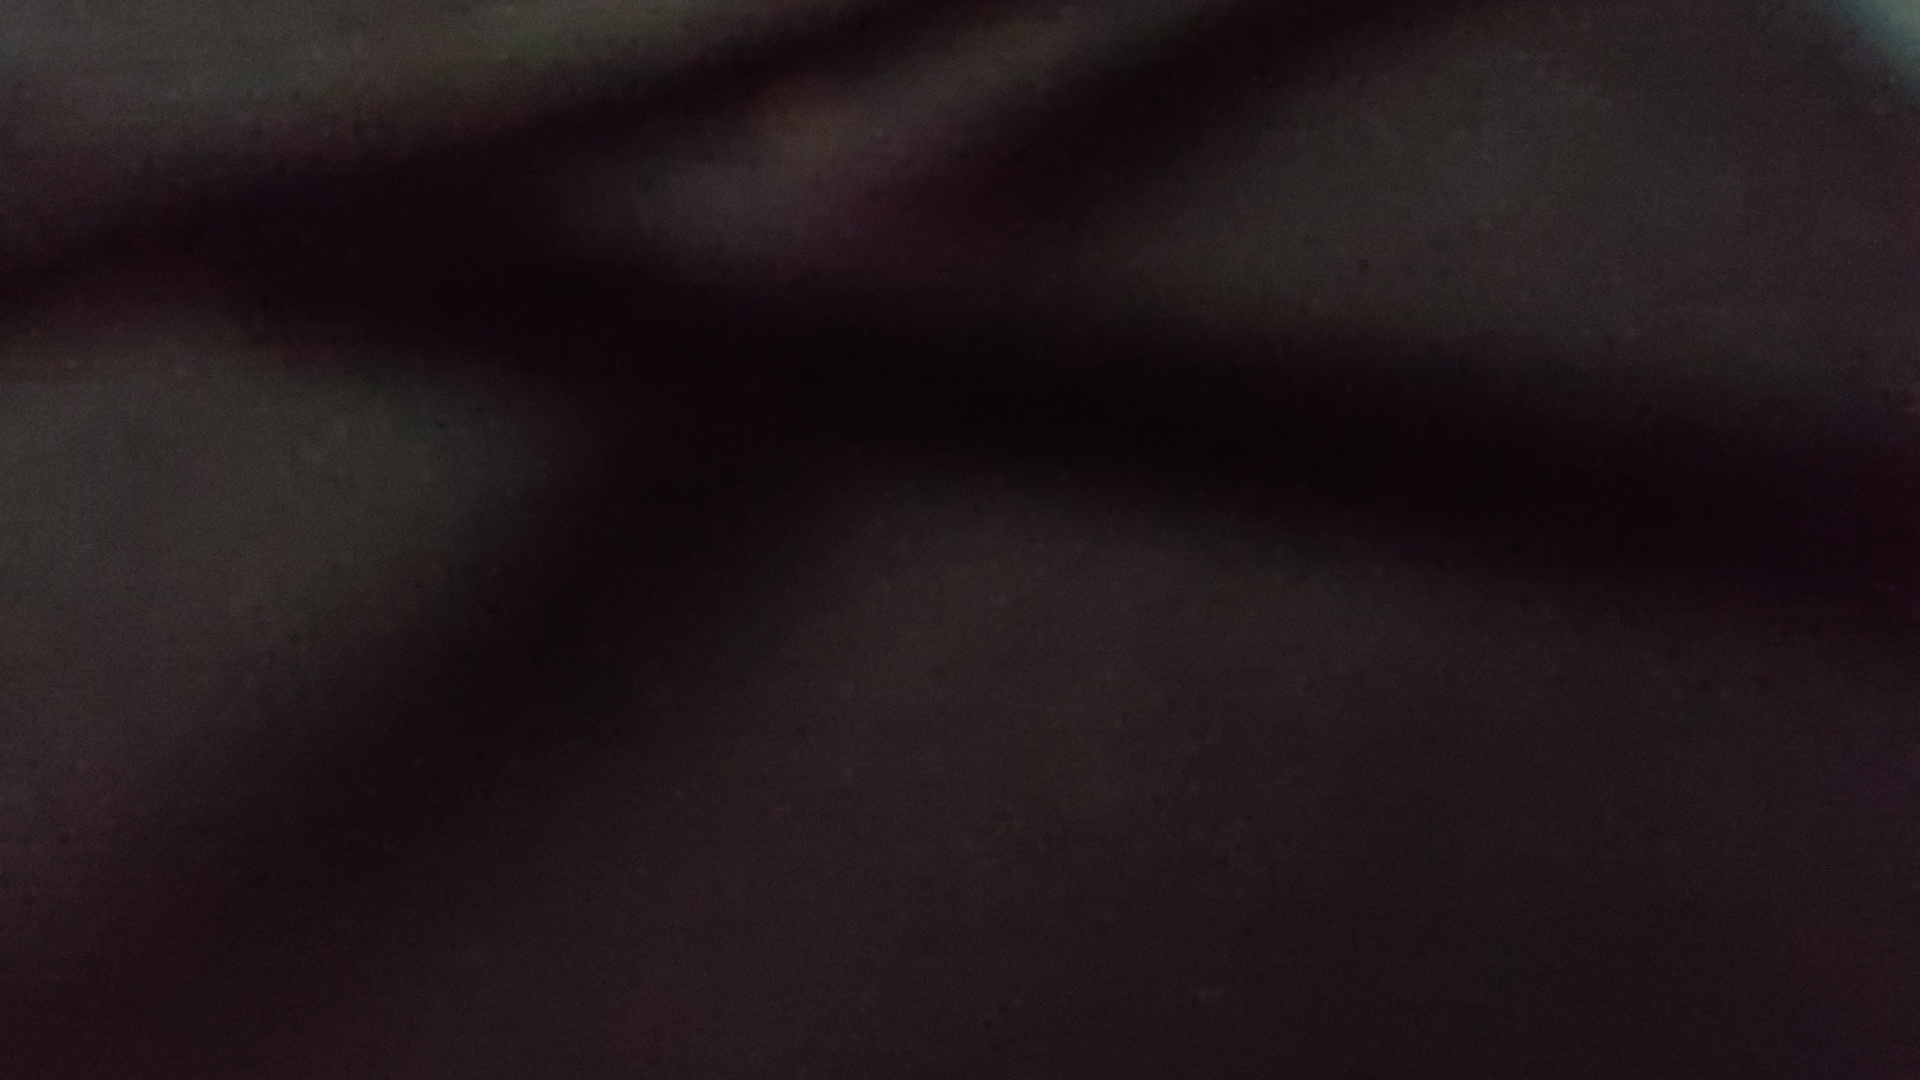

In [ ]:
from PIL import Image
image = Image.open(snapshot_file)
print(f"{snapshot_file.name}: {image.size[0]}x{image.size[1]} pixels")
image

## What's next

**Step 3:** open [03-poll.ipynb](03-poll.ipynb) — we *use* both functions and learn the polling pattern (frames, sleep, KeyboardInterrupt).